In [1]:
import torch

torch.cuda

<module 'torch.cuda' from 'f:\\PyTorch_GPU\\torch_gpu\\lib\\site-packages\\torch\\cuda\\__init__.py'>

In [2]:
if torch.cuda == "CUDA":
    print(True)
else:
    False

In [ ]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import os


class AISDataset(Dataset):
    def __init__(
        self, pkl_path, seq_len=10, target_step=1, feature_cols=None, target_cols=None
    ):
        """
        Args:
            pkl_path (str): path to .pkl AIS file
            seq_len (int): number of past timesteps in input
            target_step (int): how far ahead to predict (e.g. next 5 minutes)
            feature_cols (list): list of feature column names
            target_cols (list): list of target column names
        """
        self.seq_len = seq_len
        self.target_step = target_step

        # Load the preprocessed .pkl file
        self.df = pd.read_pickle(pkl_path)
        self.df = self.df.sort_values(by=["MMSI", "BaseDateTime"]).reset_index(
            drop=True
        )

        # Default feature/target selection
        self.feature_cols = feature_cols
        self.target_cols = target_cols or ["LAT", "LON", "SOG", "COG"]

        # Group by vessel MMSI (so we handle multiple ships cleanly)
        self.groups = [x for _, x in self.df.groupby("MMSI")]

        # Normalize (optional)
        self._normalize_features()

        # Build index mapping for sequence slicing
        self.indices = self._build_index_map()

    def _normalize_features(self):
        """Scale features between 0-1 for stable training."""
        for col in self.feature_cols:
            col_min = self.df[col].min()
            col_max = self.df[col].max()
            self.df[col] = (self.df[col] - col_min) / (col_max - col_min + 1e-8)

    def _build_index_map(self):
        """Precompute valid (group_idx, start_idx) pairs for sequence extraction."""
        index_map = []
        for g_idx, g in enumerate(self.groups):
            if len(g) > self.seq_len + self.target_step:
                for i in range(len(g) - self.seq_len - self.target_step):
                    index_map.append((g_idx, i))
        return index_map

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        g_idx, start_idx = self.indices[idx]
        g = self.groups[g_idx]

        X = g[self.feature_cols].iloc[start_idx : start_idx + self.seq_len].values
        y = (
            g[self.target_cols]
            .iloc[start_idx + self.seq_len + self.target_step - 1]
            .values
        )

        # Convert to tensors
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return X, y

In [ ]:
import pandas as pd

PKL_PATH = "processed_data/AIS_2020_01_03.pkl"
df = pd.read_pickle(PKL_PATH)

print("✅ Columns in dataset:")
print(df.columns.tolist())

print("\nSample rows:")
print(df.head())

✅ Columns in dataset:
['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo', 'TransceiverClass', 'hour', 'dayofweek', 'month', 'is_weekend', 'v_x', 'v_y', 'turn_rate', 'accel_knots_per_hr', 'is_stopped', 'Δt_hours', 'ΔCOG', 'ΔSOG', 'COG_rad', 'IMO_IMO0000000', 'IMO_IMO0000001', 'IMO_IMO0000019', 'IMO_IMO0000032', 'IMO_IMO0000111', 'IMO_IMO0000168', 'IMO_IMO0001242', 'IMO_IMO0507027', 'IMO_IMO0600071', 'IMO_IMO0606904', 'IMO_IMO0801801', 'IMO_IMO0972768', 'IMO_IMO1002055', 'IMO_IMO1002093', 'IMO_IMO10024346', 'IMO_IMO1002990', 'IMO_IMO1003621', 'IMO_IMO1003970', 'IMO_IMO100538269', 'IMO_IMO1006269', 'IMO_IMO100633661', 'IMO_IMO1006544', 'IMO_IMO1006738', 'IMO_IMO1006881', 'IMO_IMO1006910', 'IMO_IMO1007237', 'IMO_IMO1007328', 'IMO_IMO1007419', 'IMO_IMO1007445', 'IMO_IMO1007677', 'IMO_IMO1007770', 'IMO_IMO1007835', 'IMO_IMO1007914', 'IMO_IMO1008267', 'IMO_IMO1008413', 'IMO_IMO1008504', 'IMO_IMO

In [ ]:
feature_cols = [
    "LAT",
    "LON",
    "SOG",
    "COG",
    "Heading",
    "v_x",
    "v_y",
    "turn_rate",
    "accel_knots_per_hr",
    "is_stopped",
    "Δt_hours",
    "ΔCOG",
    "ΔSOG",
    "hour",
    "dayofweek",
    "is_weekend",
]

target_cols = ["LAT", "LON"]

In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np


class AISDataset(Dataset):
    def __init__(self, data, seq_len, target_step, feature_cols, target_cols):
        """
        Args:
            data (pd.DataFrame or dict): preprocessed AIS data (single or multiple vessels)
            seq_len (int): input sequence length
            target_step (int): how many steps ahead to predict
            feature_cols (list): columns used as input features
            target_cols (list): columns used as prediction targets
        """
        self.seq_len = seq_len
        self.target_step = target_step
        self.feature_cols = feature_cols
        self.target_cols = target_cols

        # Normalize input
        if isinstance(data, dict):
            self.data_dict = data
        else:
            self.data_dict = {"default": data}

        # Pre-build all sequences
        self.samples = []
        for name, df in self.data_dict.items():
            df = df.sort_values("BaseDateTime").reset_index(drop=True)
            for i in range(len(df) - seq_len - target_step):
                self.samples.append((name, i))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        vessel_name, start = self.samples[idx]
        df = self.data_dict[vessel_name]

        end = start + self.seq_len
        target_idx = end + self.target_step - 1

        X = df.iloc[start:end][self.feature_cols].values.astype(np.float32)
        y = df.iloc[target_idx][self.target_cols].values.astype(np.float32)

        return torch.tensor(X), torch.tensor(y)

In [ ]:
import pandas as pd
from torch.utils.data import DataLoader

# Load your preprocessed daywise .pkl
df = pd.read_pickle("processed_data\AIS_2020_01_03.pkl")

# Optional: group by MMSI or Day for vessel-wise sequence generation
vessel_dict = {mmsi: v for mmsi, v in df.groupby("MMSI")}

dataset = AISDataset(
    data=vessel_dict,
    seq_len=30,  # 30 timesteps per sequence
    target_step=1,  # predict next step
    feature_cols=feature_cols,
    target_cols=target_cols,
)

loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0)

KeyboardInterrupt: 

In [ ]:
for X, y in loader:
    print("X shape:", X.shape)  # [batch, seq_len, num_features]
    print("y shape:", y.shape)  # [batch, num_targets]
    break

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from tqdm import tqdm


# -------------------------------
# Lazy AIS Dataset (no per-vessel storage)
# -------------------------------
class AISDatasetLazyV2(Dataset):
    def __init__(self, df, seq_len, target_step, feature_cols, target_cols):
        """
        Args:
            df (pd.DataFrame): preprocessed AIS data
            seq_len (int): input sequence length
            target_step (int): how many steps ahead to predict
            feature_cols (list): columns used as input features
            target_cols (list): columns used as prediction targets
        """
        self.df = df.sort_values(["MMSI", "BaseDateTime"]).reset_index(drop=True)
        self.seq_len = seq_len
        self.target_step = target_step
        self.feature_cols = feature_cols
        self.target_cols = target_cols

        # Store per-vessel start and end indices
        self.vessel_bounds = {}
        self.indices = []  # (vessel_mmsi, start_idx)
        for mmsi, group in self.df.groupby("MMSI"):
            start_idx = group.index[0]
            n = len(group)
            if n > seq_len + target_step:
                for i in range(n - seq_len - target_step):
                    self.indices.append((mmsi, start_idx + i))
                self.vessel_bounds[mmsi] = (start_idx, start_idx + n - 1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        mmsi, start = self.indices[idx]
        start_bound, end_bound = self.vessel_bounds[mmsi]
        end = start + self.seq_len
        target_idx = end + self.target_step - 1

        # Slice from main DataFrame
        X = self.df.loc[start : end - 1, self.feature_cols].values.astype(np.float32)
        y = self.df.loc[target_idx, self.target_cols].values.astype(np.float32)

        return torch.tensor(X), torch.tensor(y)


# -------------------------------
# Configuration
# -------------------------------
feature_cols = [
    "LAT",
    "LON",
    "SOG",
    "COG",
    "Heading",
    "v_x",
    "v_y",
    "turn_rate",
    "accel_knots_per_hr",
    "is_stopped",
    "Δt_hours",
    "ΔCOG",
    "ΔSOG",
    "hour",
    "dayofweek",
    "is_weekend",
]
target_cols = ["LAT", "LON"]

SEQ_LEN = 30
TARGET_STEP = 1
BATCH_SIZE = 16
NUM_WORKERS = 0  # Windows safe

# -------------------------------
# Load Data
# -------------------------------
df = pd.read_pickle(r"processed_data\AIS_2020_01_03.pkl")

dataset = AISDatasetLazyV2(
    df=df,
    seq_len=SEQ_LEN,
    target_step=TARGET_STEP,
    feature_cols=feature_cols,
    target_cols=target_cols,
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# -------------------------------
# GPU Setup
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# Iterate with tqdm
# -------------------------------
for X, y in tqdm(loader, desc="Processing Batches"):
    X = X.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)


# -------------------------------
# Optional: Cache to disk for later use
# -------------------------------
torch.save(dataset, "processed_data/ais_dataset_lazyv3_2020_01_03.pt")
print("✅ Dataset saved for later use")

Using device: cuda


Processing Batches:   0%|          | 1320/418733 [1:12:50<383:53:59,  3.31s/it]


KeyboardInterrupt: 

In [3]:
df_1 = pd.read_pickle(r"processed_data\AIS_2020_01_03.pkl")
df_1.head(25)

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,CallSign,VesselType,...,IMO_IMO9835812,IMO_IMO9836397,IMO_IMO9836402,IMO_IMO9837212,IMO_IMO9840532,IMO_IMO9840685,IMO_IMO9840740,IMO_IMO9841691,IMO_IMO9849942,IMO_IMO999975000
0,18,2020-01-03 00:00:40,27.85054,-97.23628,0.0,149.7,511.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1,18,2020-01-03 00:03:44,27.85055,-97.23632,0.0,186.1,511.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
2,18,2020-01-03 00:06:43,27.85055,-97.23629,0.0,181.6,511.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
3,18,2020-01-03 00:09:45,27.85055,-97.23621,0.0,175.5,511.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
4,18,2020-01-03 00:12:45,27.85057,-97.23626,0.0,180.3,511.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
5,18,2020-01-03 00:15:44,27.85056,-97.23626,0.0,171.2,511.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
6,18,2020-01-03 00:18:41,27.85052,-97.23634,0.0,160.5,511.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
7,18,2020-01-03 00:21:43,27.85056,-97.23629,0.0,158.5,511.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
8,18,2020-01-03 00:24:46,27.85058,-97.23624,0.0,191.6,511.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
9,18,2020-01-03 00:27:43,27.85058,-97.23634,0.0,207.4,511.0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
len(df_1["MMSI"].unique())

12572

In [8]:
df_1.shape

(7089446, 3992)

In [9]:
df_1.describe()

f:\PyTorch_GPU\torch_gpu\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
f:\PyTorch_GPU\torch_gpu\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselType,Status,Length,...,dayofweek,month,v_x,v_y,turn_rate,accel_knots_per_hr,Δt_hours,ΔCOG,ΔSOG,COG_rad
count,7.089446e+06,7089446,7.089446e+06,7.089446e+06,7.089446e+06,7.089446e+06,7.089446e+06,6.369414e+06,5.548081e+06,5.960398e+06,...,7089446.0,7089446.0,7.089446e+06,7.089446e+06,6.712489e+06,5961263.0,7.089446e+06,7.089446e+06,7.089446e+06,7.089446e+06
mean,3.669435e+08,2020-01-03 12:10:57.832504064,3.516819e+01,-9.574144e+01,2.020630e+00,2.093964e+02,3.665675e+02,4.370034e+01,4.205055e+00,4.777773e+01,...,4.0,1.0,1.862209e-01,1.312845e-02,NaN,NaN,3.849756e-02,-6.930117e-03,2.773701e-04,3.654655e+00
min,1.800000e+01,2020-01-03 00:00:00,7.086550e+00,-1.783058e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.0,1.0,-1.021874e+02,-1.011804e+02,-inf,-inf,0.000000e+00,-1.800000e+02,-1.023000e+02,0.000000e+00
25%,3.669059e+08,2020-01-03 06:07:15,2.961845e+01,-1.171664e+02,0.000000e+00,1.214000e+02,2.140000e+02,3.100000e+01,0.000000e+00,1.800000e+01,...,4.0,1.0,0.000000e+00,0.000000e+00,-1.518753e+02,0.0,3.555556e-02,-2.399994e+00,0.000000e+00,2.118830e+00
50%,3.673872e+08,2020-01-03 12:23:53,3.264749e+01,-9.039992e+01,0.000000e+00,2.292000e+02,5.110000e+02,3.100000e+01,0.000000e+00,2.400000e+01,...,4.0,1.0,-0.000000e+00,0.000000e+00,0.000000e+00,0.0,3.555556e-02,0.000000e+00,0.000000e+00,4.000295e+00
75%,3.677051e+08,2020-01-03 18:14:10,4.064072e+01,-8.088758e+01,4.000000e-01,3.014000e+02,5.110000e+02,6.000000e+01,7.000000e+00,4.000000e+01,...,4.0,1.0,-0.000000e+00,-0.000000e+00,1.518757e+02,0.0,3.555556e-02,2.400024e+00,0.000000e+00,5.260422e+00
max,1.073709e+09,2020-01-03 23:59:59,7.049003e+01,1.449452e+02,1.023000e+02,3.797000e+02,5.110000e+02,9.900000e+01,1.500000e+01,3.670000e+02,...,4.0,1.0,1.023000e+02,9.778635e+01,inf,inf,2.243556e+01,1.800000e+02,1.023000e+02,6.627015e+00
std,5.744350e+07,NaN,8.392292e+00,2.225764e+01,5.947170e+00,1.110125e+02,1.771185e+02,1.978139e+01,5.713811e+00,6.397324e+01,...,0.0,0.0,5.424419e+00,3.161110e+00,NaN,NaN,1.309381e-01,4.377496e+01,1.972530e+00,1.937533e+00


In [ ]:
df_1.columns

Index(['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading',
       'VesselName', 'CallSign', 'VesselType',
       ...
       'IMO_IMO9835812', 'IMO_IMO9836397', 'IMO_IMO9836402', 'IMO_IMO9837212',
       'IMO_IMO9840532', 'IMO_IMO9840685', 'IMO_IMO9840740', 'IMO_IMO9841691',
       'IMO_IMO9849942', 'IMO_IMO999975000'],
      dtype='object', length=3992)

In [ ]:
import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from collections import defaultdict
from math import radians, sin, cos, sqrt, atan2

import geopandas as gpd
from shapely.geometry import Point, MultiPoint
import folium

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from tqdm import tqdm

In [ ]:
OUTPUT_DIR = "outputs_pipeline"
os.makedirs(OUTPUT_DIR, exist_ok=True)

INPUT_FEATURES = [
    "LAT",
    "LON",
    "SOG",
    "COG",
    "Heading",
    "v_x",
    "v_y",
    "turn_rate",
    "accel_knots_per_hr",
    "dayofweek",
    "month",
    "Δt_hours",
    "ΔCOG",
    "ΔSOG",
    "COG_rad",
]
TARGET_FEATURES = ["LAT", "LON", "SOG", "COG", "Heading"]

SEQ_LEN = 10
PRED_LEN = 1
BATCH_SIZE = 128
EPOCHS = 12
LR = 1e-3
HIDDEN_DIM = 128
NUM_LAYERS = 2

In [ ]:
PKL_PATH = "processed_data\AIS_2020_01_03.pkl"


def load_df(path=PKL_PATH):

    print(f"Loading dataframe from: {path}")
    df = pd.read_pickle(path)
    df = df.sort_values(["MMSI", "BaseDateTime"]).reset_index(drop=True)
    return df

In [ ]:
def detect_issues(df, features, large_threshold=1e6):
    """Return diagnostics DataFrame: counts of inf/nan/large/outlier_zscore>3.2"""
    diag = []
    for col in features:
        series = df[col]
        infs = np.isinf(series).sum()
        nans = series.isna().sum()
        large = (series.abs() > large_threshold).sum()
        # zscore outlier detection (skip NaNs/infs)
        vals = pd.to_numeric(series, errors="coerce")
        z = (vals - vals.mean()) / (vals.std() + 1e-12)
        outliers = (z.abs() > 3.2).sum()
        diag.append(
            {
                "feature": col,
                "inf": int(infs),
                "nan": int(nans),
                ">1e6": int(large),
                "z_outliers": int(outliers),
            }
        )
    return pd.DataFrame(diag)


def plot_health_heatmap(diag_df, outpath=None):
    dfm = diag_df.set_index("feature")[["inf", "nan", "z_outliers", ">1e6"]]
    plt.figure(figsize=(10, max(4, 0.4 * len(dfm))))
    sns.heatmap(np.log1p(dfm), annot=dfm, fmt="g", cmap="Reds")
    plt.title("Data health diagnostics (log1p counts)")
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=150)
    plt.show()


def clean_ais_features(df, feature_cols, clip_range=(-1e3, 1e3), fill_value=0):
    df = df.copy()
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    df[feature_cols] = df[feature_cols].fillna(fill_value)
    df[feature_cols] = df[feature_cols].clip(*clip_range)
    return df

In [ ]:
def kmeans_clusters(df, n_clusters=8, sample_frac=1.0, random_state=42):
    sample = (
        df.sample(frac=sample_frac, random_state=random_state)
        if sample_frac < 1.0
        else df
    )
    coords = sample[["LAT", "LON"]].values
    scaler = StandardScaler()
    coords_s = scaler.fit_transform(coords)
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    labels = kmeans.fit_predict(coords_s)
    sample = sample.copy()
    sample["cluster"] = labels
    # assign labels back to original (approx) by nearest (for full df, we rerun prediction)
    full_coords_s = scaler.transform(df[["LAT", "LON"]].values)
    df = df.copy()
    df["cluster"] = kmeans.predict(full_coords_s)
    return df, kmeans


def clusters_to_polygons(df, cluster_col="cluster"):
    gpd_clusters = []
    for lab, grp in df.groupby(cluster_col):
        points = [Point(xy) for xy in zip(grp["LON"], grp["LAT"])]
        if len(points) == 0:
            continue
        m = MultiPoint(points)
        hull = m.convex_hull
        gpd_clusters.append(
            {"cluster": int(lab), "geometry": hull, "count": len(points)}
        )
    gdf = gpd.GeoDataFrame(gpd_clusters)
    return gdf


def folium_cluster_map(df, gdf_polys=None, cluster_col="cluster", save_path=None):
    # center map
    mean_lat = df["LAT"].mean()
    mean_lon = df["LON"].mean()
    m = folium.Map(location=[mean_lat, mean_lon], zoom_start=6)
    # color palette
    import branca

    n = df[cluster_col].nunique()
    palette = branca.colormap.linear.Set1_09.scale(0, max(1, n - 1))
    # add polygons
    if gdf_polys is not None:
        for _, row in gdf_polys.iterrows():
            coords = [(y, x) for x, y in row["geometry"].exterior.coords]
            folium.Polygon(
                coords,
                color=palette(row["cluster"]),
                weight=2,
                fill=True,
                fill_opacity=0.1,
                popup=f"cluster {row['cluster']} count {row['count']}",
            ).add_to(m)
    # add sample markers (downsample)
    sample = df.sample(min(2000, len(df)), random_state=1)
    for _, r in sample.iterrows():
        folium.CircleMarker(
            location=[r["LAT"], r["LON"]],
            radius=2,
            fill=True,
            color=palette(int(r[cluster_col])),
            opacity=0.7,
        ).add_to(m)
    if save_path:
        m.save(save_path)
    return m

In [ ]:
def run_pca(df, features, n_components=10):
    X = df[features].copy()
    X = X.fillna(0)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(Xs)
    loadings = pd.DataFrame(
        pca.components_.T,
        index=features,
        columns=[f"PC{i+1}" for i in range(n_components)],
    )
    explained = pca.explained_variance_ratio_
    return pca, pcs, loadings, explained

In [ ]:
def plot_pca_results(explained, loadings, outprefix):
    plt.figure(figsize=(8, 4))
    plt.plot(np.cumsum(explained) * 100)
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative explained variance (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(outprefix + "_explained.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, max(4, 0.4 * len(loadings))))
    sns.heatmap(loadings, annot=True, cmap="coolwarm")
    plt.title("PCA loadings")
    plt.tight_layout()
    plt.savefig(outprefix + "_loadings.png", dpi=150)
    plt.show()

In [ ]:
# ----------------------------
# Haversine
# ----------------------------


def haversine(lat1, lon1, lat2, lon2):
    R = 6371e3  # radius of earth
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dl = radians(lon2 - lon1)
    a = sin(dphi / 2) ** 2 + cos(phi1) * cos(phi2) * sin(dl / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

In [ ]:
# ----------------------------
# Dataset and Model
# ----------------------------
class VesselSequenceDataset(Dataset):
    def __init__(self, df, input_features, target_features, seq_len=10, pred_len=1):
        self.samples = []
        self.input_features = input_features
        self.target_features = target_features
        self.seq_len = seq_len
        self.pred_len = pred_len
        for mmsi, grp in df.groupby("MMSI"):
            X = grp[input_features].values
            Y = grp[target_features].values
            n = len(X)
            for i in range(n - seq_len - pred_len + 1):
                x = X[i : i + seq_len]
                y = Y[i + seq_len : i + seq_len + pred_len]
                self.samples.append(
                    (int(mmsi), x.astype(np.float32), y.astype(np.float32))
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        mmsi, x, y = self.samples[idx]
        return torch.from_numpy(x), torch.from_numpy(y).squeeze(0), mmsi


class VesselLSTM(nn.Module):
    def __init__(
        self, input_dim, hidden_dim=128, num_layers=2, output_dim=5, dropout=0.2
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Linear(64, output_dim)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [ ]:
# ----------------------------
# Training and evaluation
# ----------------------------


def train_model(model, train_loader, val_loader, config, save_prefix):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    writer = SummaryWriter(log_dir=os.path.join(OUTPUT_DIR, "runs", save_prefix))
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(config["epochs"]):
        model.train()
        tl = 0
        for X, y, _ in train_loader:
            X = X.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            tl += loss.item()
        train_loss = tl / len(train_loader)

        # val
        model.eval()
        vl = 0
        with torch.no_grad():
            for Xv, yv, _ in val_loader:
                Xv = Xv.to(device)
                yv = yv.to(device)
                pv = model(Xv)
                lossv = criterion(pv, yv)
                vl += lossv.item()
        val_loss = vl / len(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        print(
            f"Epoch {epoch+1}/{config['epochs']} Train:{train_loss:.6f} Val:{val_loss:.6f}"
        )

    # save
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f"{save_prefix}_model.pt"))
    pd.DataFrame(history).to_csv(
        os.path.join(OUTPUT_DIR, f"{save_prefix}_history.csv"), index=False
    )
    writer.close()
    return history

In [ ]:
def evaluate_per_mmsi(model, loader, scaler_out, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    per_vessel_rmse = defaultdict(list)
    per_vessel_hav = defaultdict(list)
    with torch.no_grad():
        for X, y, mmsi in loader:
            X = X.to(device)
            y = y.to(device)
            preds = model(X)
            # inverse scale assumed handled outside; here we return scaled metric too
            pred_np = preds.cpu().numpy()
            y_np = y.cpu().numpy()
            for i, vid in enumerate(mmsi):
                # positional RMSE in scaled units
                pos_rmse = np.sqrt(
                    (pred_np[i, 0] - y_np[i, 0]) ** 2
                    + (pred_np[i, 1] - y_np[i, 1]) ** 2
                )
                per_vessel_rmse[int(vid)].append(pos_rmse)
                # Haversine requires unscaled lat/lon; skip here or provide unscaled arrays
    # aggregate
    per_vessel_rmse_mean = {
        vid: float(np.mean(v)) for vid, v in per_vessel_rmse.items()
    }
    return per_vessel_rmse_mean

In [27]:
# ----------------------------
# Visualization helpers
# ----------------------------


def plot_loss(history_csv_path):
    df = pd.read_csv(history_csv_path)
    plt.figure()
    plt.plot(df["train_loss"], label="train")
    plt.plot(df["val_loss"], label="val")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_top_vessels_errors(vessel_error_dict, top_k=10, outpath=None):
    items = sorted(vessel_error_dict.items(), key=lambda x: x[1])
    ids = [str(i) for i, _ in items[:top_k]]
    errs = [e for _, e in items[:top_k]]
    plt.figure(figsize=(8, 4))
    sns.barplot(x=ids, y=errs)
    plt.xticks(rotation=45)
    plt.ylabel("mean pos RMSE (scaled)")
    plt.title("Top vessels (lowest error)")
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=150)
    plt.show()

Loading dataframe from: processed_data\AIS_2020_01_03.pkl


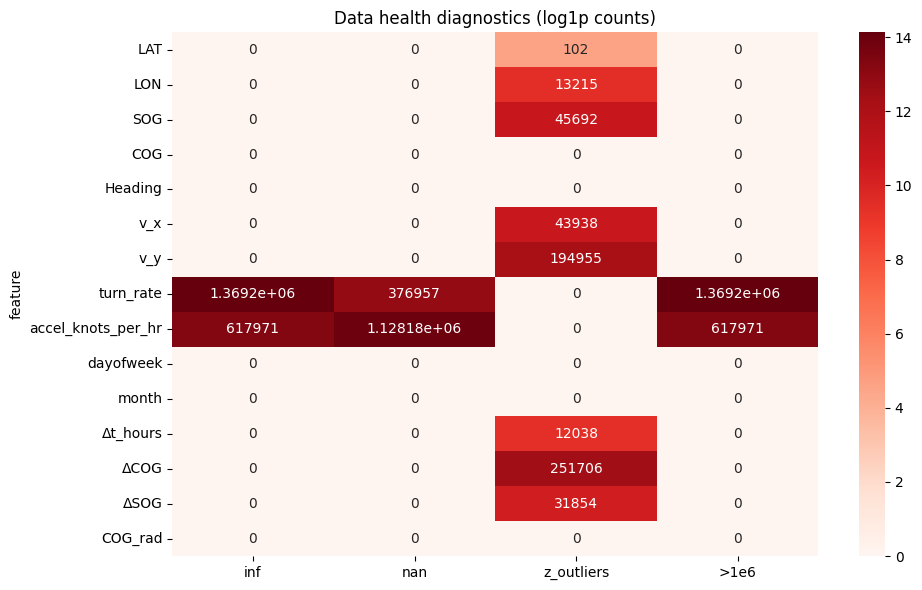

Saved cluster map to outputs_pipeline/clusters_map.html


MemoryError: Unable to allocate 1.11 GiB for an array with shape (21, 7089446) and data type float64

In [28]:
# ----------------------------
# Main pipeline
# ----------------------------


def main():
    df = load_df(PKL_PATH)

    # Diagnostics
    diag = detect_issues(df, INPUT_FEATURES)
    diag.to_csv(os.path.join(OUTPUT_DIR, "diagnostics.csv"), index=False)
    plot_health_heatmap(
        diag, outpath=os.path.join(OUTPUT_DIR, "diagnostics_heatmap.png")
    )

    # Clean
    df_clean = clean_ais_features(
        df, INPUT_FEATURES, clip_range=(-1e3, 1e3), fill_value=0
    )

    # Scale for modeling
    scaler_in = MinMaxScaler()
    scaler_out = MinMaxScaler()
    df_clean[INPUT_FEATURES] = scaler_in.fit_transform(df_clean[INPUT_FEATURES])
    df_clean[TARGET_FEATURES] = scaler_out.fit_transform(df_clean[TARGET_FEATURES])

    # Clustering & map
    df_clustered, kmeans = kmeans_clusters(df_clean, n_clusters=8, sample_frac=0.2)
    gdf_polys = clusters_to_polygons(df_clustered)
    fmap = folium_cluster_map(
        df_clustered, gdf_polys, save_path=os.path.join(OUTPUT_DIR, "clusters_map.html")
    )
    print("Saved cluster map to outputs_pipeline/clusters_map.html")

    # PCA
    pca, pcs, loadings, explained = run_pca(
        df_clean.dropna(subset=INPUT_FEATURES),
        INPUT_FEATURES,
        n_components=min(10, len(INPUT_FEATURES)),
    )
    plot_pca_results(explained, loadings, outprefix=os.path.join(OUTPUT_DIR, "pca"))
    loadings.to_csv(os.path.join(OUTPUT_DIR, "pca_loadings.csv"))

    # Prepare dataset and split
    dataset = VesselSequenceDataset(
        df_clean, INPUT_FEATURES, TARGET_FEATURES, seq_len=SEQ_LEN, pred_len=PRED_LEN
    )
    idx = np.arange(len(dataset))
    # simple 90/10 split (random indices)
    from sklearn.model_selection import train_test_split

    train_idx, test_idx = train_test_split(idx, test_size=0.1, random_state=42)
    train_ds = torch.utils.data.Subset(dataset, train_idx)
    test_ds = torch.utils.data.Subset(dataset, test_idx)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # Model
    model = VesselLSTM(
        input_dim=len(INPUT_FEATURES),
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        output_dim=len(TARGET_FEATURES),
    )
    cfg = {"epochs": EPOCHS, "lr": LR}
    history = train_model(
        model, train_loader, test_loader, cfg, save_prefix="vessel_lstm"
    )

    # Evaluate per MMSI (note: we used scaled coords; for haversine you must inverse-transform)
    vessel_rmse = evaluate_per_mmsi(model, test_loader, scaler_out)
    pd.DataFrame(
        [{"MMSI": k, "mean_pos_rmse_scaled": v} for k, v in vessel_rmse.items()]
    ).to_csv(os.path.join(OUTPUT_DIR, "per_mmsi_rmse.csv"), index=False)
    plot_top_vessels_errors(
        vessel_rmse,
        top_k=15,
        outpath=os.path.join(OUTPUT_DIR, "top_vessels_errors.png"),
    )

    print("Pipeline finished. Outputs in", OUTPUT_DIR)


if __name__ == "__main__":
    main()